# QUA — Câu hỏi 2: Hiệu quả điều trị **AAV9 vs LICA1**

**Micro-dystrophin gene therapy · cùng liều · so sánh serotype AAV9 vs LICA1 (myotropic)**

## Mục tiêu & giả thuyết
Cả AAV9 và LICA1 đều chuyển gene **micro-dystrophin** cùng liều, khác nhau ở capsid/serotype dùng để
tải gene. Giả thuyết của nhóm: **LICA1 (myotropic) phục hồi tốt hơn AAV9**. Ta lượng hóa: (i) dịch chuyển
thành phần cluster về phía WT, (ii) phục hồi dystrophin ở màng, (iii) giảm viêm/hoại tử, (iv) phục hồi các
tương quan bị mất — và kiểm tra khung *Cls2/3/4/6 responsive, Cls5 resistant*.

## Nguyên tắc reproducibility (giống Notebook 1)
- Dùng **precomputed** UMAP cache; **không** re-cluster; tái lập GMM k=6 deterministic (`seed=42`).
- Thống kê **per-animal** (median mỗi con vật) + MWU + Cohen's d. n = 5 WT / 5 mdx / **4 AAV9** / 5 LICA1.
- **Loại AAV9 khỏi mọi phân tích slide-8** (LAMP2/LGALS3/SQSTM1): mapping AAV9 chỉ ~16% (không tin cậy).
- Chỉ dùng giá trị **observed**; NADH/COX cao = oxidative cao (đã kiểm định thực nghiệm).

### 1 · Thiết lập (self-contained, reproducible)

In [1]:
# === Self-contained, reproducible setup (no /DATA symlink, no external bundle) ===
# Reproduces the analysis matrix from the repo's PRECOMPUTED UMAP cache.
# Clustering (PCA+UMAP) is NOT re-run: we load the cached embedding and reproduce
# only the deterministic GMM labelling (random_state=42), exactly as the repo's
# plot_umap.py does. This guarantees the same 6 clusters every run.
import os, sys, pickle, warnings, hashlib
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

# ---- locate repo root (works from scripts/, notebooks/, or repo root) ----
def find_repo_root():
    for base in [Path.cwd()] + list(Path.cwd().parents):
        if (base / "config" / "ddc_config.py").exists() and (base / "results" / "QUA").exists():
            return base
    for cand in [Path("/home/user/F2FMatcher_DDC"), Path("/DATA/F2FMatcher_DDC")]:
        if (cand / "config" / "ddc_config.py").exists():
            return cand
    raise RuntimeError("Cannot locate F2FMatcher_DDC repo root")
REPO = find_repo_root()
sys.path.insert(0, str(REPO))
from config.ddc_config import (SLIDES, MASK_FEATURES, QUA_SAMPLES, GROUP_MAP,
                               get_group, FEATURE_STATISTICS, ANALYSIS_CONFIG)

MUSCLE = "QUA"
RES = REPO / "results" / MUSCLE
COMBINED = RES / "features_combined"
CACHE = RES / "clustering_cache" / "ch3_zscore_pca30_mindist0.0_nn15.npz"
COMPARTMENT_ORDER = ["whole", "mem", "cyto1", "cyto2"]
RANDOM_STATE = ANALYSIS_CONFIG["random_state"]   # 42
GROUPS = ["WT", "mdx", "AAV9", "LICA1"]
GCOL = {"WT": "#0000C0", "mdx": "#FF6000", "AAV9": "#C0C000", "LICA1": "#008000"}
CLUSTER_COLORS = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628"]
CLUSTERS = [1, 2, 3, 4, 5, 6]
K = 6

def feature_columns():
    """807-col combined vector layout: 15 mask + 36 per channel (22 channels)."""
    cols = list(MASK_FEATURES)
    for slide in SLIDES:
        for ch, stain in SLIDES[slide]["stainings"].items():
            for comp in COMPARTMENT_ORDER:
                for stat in FEATURE_STATISTICS:
                    cols.append(f"S{slide}_{stain}_{comp}_{stat}")
    return cols

def slide_channel_blocks():
    blocks, off = {}, 0
    for slide in SLIDES:
        n = len(SLIDES[slide]["stainings"]); blocks[slide] = (off, n); off += n
    return blocks

def load_all_full():
    """Full 807-feature matrix for all QUA fibers (row order == cluster cache order)."""
    frames = []
    for s in QUA_SAMPLES:
        with open(COMBINED / f"{s}.pkl", "rb") as f:
            d = pickle.load(f)
        for lid, vec in d.items():
            frames.append(list(vec) + [lid, s, get_group(s)])
    cols = feature_columns() + ["label_id", "sample", "group"]
    return pd.DataFrame(frames, columns=cols)

def build_analysis_frame(verbose=True):
    """Load precomputed UMAP cache, reproduce GMM(k=6) labels, align full features.
    Cached to results/QUA/clustering_cache/analysis_frame_ch3_k6.npz for fast re-runs."""
    from sklearn.mixture import GaussianMixture
    fast = CACHE.parent / "analysis_frame_ch3_k6.npz"
    z = np.load(CACHE, allow_pickle=True)
    Xpca = z["X_pca"]; Xumap = z["X_umap"]
    groups = z["groups"].astype(str); samples = z["samples"].astype(str)
    # deterministic GMM labelling on the cached PCA embedding (same as plot_umap.py)
    labels = GaussianMixture(n_components=K, covariance_type="full", n_init=1,
                             max_iter=200, random_state=RANDOM_STATE).fit_predict(Xpca) + 1
    if fast.exists():
        c = np.load(fast, allow_pickle=True)
        if np.array_equal(c["samples"].astype(str), samples) and np.array_equal(c["labels"], labels):
            if verbose: print(f"Loaded aligned analysis frame from {fast.name}")
            return dict(Xpre=c["Xpre"], Xumap=Xumap, groups=groups, samples=samples,
                        labels=labels, cols=[str(x) for x in c["cols"]])
    df = load_all_full()
    full_cols = feature_columns()
    Xfull = df[full_cols].to_numpy(np.float64)
    blocks = slide_channel_blocks()
    # ch3 detection filter: fiber detected on slide 6 (HE) — reproduces the cache's rows
    st, nc = blocks[6]
    detected = (~np.isnan(Xfull[:, 15 + st*36:15 + (st+nc)*36])).any(axis=1)
    keep = detected >= 1
    Xpre = Xfull[keep]
    assert np.array_equal(df["sample"].to_numpy()[keep], samples), "row alignment mismatch"
    np.savez_compressed(fast, Xpre=Xpre, cols=np.array(full_cols),
                        samples=samples, labels=labels)
    if verbose: print(f"Built & cached aligned analysis frame -> {fast.name}")
    return dict(Xpre=Xpre, Xumap=Xumap, groups=groups, samples=samples,
                labels=labels, cols=full_cols)


In [2]:
# === Analysis helpers: marker panel, per-fiber values, per-animal statistics ===
import numpy as np, pandas as pd
from scipy import stats

# marker -> (column or [RGB cols], short biological meaning)
MARKERS = {
    "area":            ("area", "fiber cross-sectional area (size)"),
    "roundness":       ("roundness", "circularity"),
    "eccentricity":    ("eccentricity", "elongation"),
    "solidity":        ("solidity", "convexity"),
    "minor_axis":      ("minor_axis_length", "min Feret diameter"),
    "Dystrophin_mem":  ("S1_Dystrophin_mem_mean", "sarcolemmal dystrophin"),
    "Laminin_mem":     ("S1_Laminin_mem_mean", "basal-lamina laminin"),
    "Collagen4_mem":   ("S1_Collagen4_mem_mean", "peri-fiber collagen-IV / fibrosis"),
    "DAPI_cyto2":      ("S1_DAPI_cyto2_mean", "central nucleation (regeneration)"),
    "DAPI_mem":        ("S1_DAPI_mem_mean", "peripheral (normal) nuclei"),
    "IgG_whole":       ("S2_IgG_whole_mean", "IgG influx (necrosis / leaky sarcolemma)"),
    "CD11b_mem":       ("S2_CD11b_mem_mean", "CD11b+ myeloid infiltration"),
    "NADH":            (["S3_R_whole_mean","S3_G_whole_mean","S3_B_whole_mean"], "NADH-TR (oxidative; ↑=more oxidative here)"),
    "COX":             (["S7_R_whole_mean","S7_G_whole_mean","S7_B_whole_mean"], "COX (oxidative; ↑=more oxidative here)"),
    "Myh7":            ("S4_Myh7_whole_mean", "MyHC-I (slow oxidative)"),
    "Myh2":            ("S4_Myh2_whole_mean", "MyHC-IIa"),
    "Myh4":            ("S4_Myh4_whole_mean", "MyHC-IIb (fast glycolytic)"),
    "LAMP2":           ("S8_LAMP2_whole_mean", "LAMP2 (lysosomal membrane)"),
    "LGALS3":          ("S8_LGALS3_whole_mean", "galectin-3 (lysosomal damage)"),
    "SQSTM1":          ("S8_SQSTM1_whole_mean", "p62/SQSTM1 (autophagy)"),
    "HE_hematox_B":    ("S6_B_whole_mean", "HE hematoxylin (basophilia)"),
    "HE_eosin_R":      ("S6_R_whole_mean", "HE eosin"),
}
SLIDE8 = {"LAMP2", "LGALS3", "SQSTM1"}   # AAV9 mapping unreliable (15.7%) -> excluded

class QUA:
    """Bundles the analysis frame + marker accessors and per-animal statistics."""
    def __init__(self, D):
        self.Xpre = D["Xpre"]; self.Xumap = D["Xumap"]
        self.groups = D["groups"]; self.samples = D["samples"]; self.labels = D["labels"]
        self.cols = D["cols"]; self.cidx = {c: i for i, c in enumerate(self.cols)}
        self.usamp = np.unique(self.samples)
        self.sgroup = {s: self.groups[self.samples == s][0] for s in self.usamp}

    def mval(self, name):
        spec = MARKERS[name][0]
        if isinstance(spec, str):
            return self.Xpre[:, self.cidx[spec]]
        return np.nanmean(np.stack([self.Xpre[:, self.cidx[c]] for c in spec]), axis=0)

    def valid_groups(self, name):
        return [g for g in GROUPS if not (name in SLIDE8 and g == "AAV9")]

    def per_animal(self, name, cluster=None, stat="median"):
        """Per-animal summary (median by default) of observed marker; optional within-cluster."""
        v = self.mval(name); ok = ~np.isnan(v)
        if cluster is not None: ok = ok & (self.labels == cluster)
        rows = []
        for s in self.usamp:
            m = ok & (self.samples == s)
            if m.sum() >= 10:
                val = np.median(v[m]) if stat == "median" else np.mean(v[m])
                rows.append((s, self.sgroup[s], val, int(m.sum())))
        return pd.DataFrame(rows, columns=["sample", "group", "val", "n"])

    def cluster_fraction(self):
        rows = []
        for s in self.usamp:
            m = self.samples == s
            r = {"sample": s, "group": self.sgroup[s]}
            for c in CLUSTERS: r[f"Cls{c}"] = (self.labels[m] == c).mean() * 100
            rows.append(r)
        return pd.DataFrame(rows)

def cohens_d(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2: return np.nan
    sp = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / sp if sp > 0 else np.nan

def mwu(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2: return np.nan
    try: return stats.mannwhitneyu(a, b, alternative="two-sided").pvalue
    except ValueError: return np.nan

def spearman_masked(a, b, nmin=50):
    m = ~np.isnan(a) & ~np.isnan(b)
    if m.sum() < nmin: return np.nan, int(m.sum())
    return stats.spearmanr(a[m], b[m]).correlation, int(m.sum())

def stars(p):
    if p is None or np.isnan(p): return "n/a"
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"


In [3]:
# === Q2 figure functions (treatment: AAV9 vs LICA1) ===
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

def _strip_by_group(ax, df, groups_use, title, ylab, ref=None):
    """per-animal points + group mean bars."""
    for i, g in enumerate(groups_use):
        vals = df[df.group == g]["val"].values
        ax.bar(i, np.mean(vals), color=GCOL[g], alpha=0.35, width=0.6, zorder=1)
        ax.scatter(np.full(len(vals), i) + np.random.RandomState(0).uniform(-.12, .12, len(vals)),
                   vals, color=GCOL[g], edgecolor="k", lw=.5, s=34, zorder=3)
        ax.hlines(np.mean(vals), i-.3, i+.3, color="k", lw=1.6, zorder=4)
    if ref is not None:
        ax.axhline(ref, ls="--", lw=1, color="#0000C0", alpha=.6, zorder=0)
    ax.set_xticks(range(len(groups_use))); ax.set_xticklabels(groups_use)
    ax.set_title(title, fontsize=10.5, fontweight="bold"); ax.set_ylabel(ylab)

def fig_cluster_composition(q, out):
    F = q.cluster_fraction()
    gm = F.groupby("group")[[f"Cls{c}" for c in CLUSTERS]].mean().reindex(GROUPS)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
    bottom = np.zeros(4)
    for c in CLUSTERS:
        vals = gm[f"Cls{c}"].values
        ax[0].bar(GROUPS, vals, bottom=bottom, color=CLUSTER_COLORS[c-1], label=f"Cls{c}")
        bottom += vals
    ax[0].set_ylabel("% of fibers"); ax[0].legend(ncol=3, fontsize=8, loc="lower center")
    ax[0].set_title("Cluster composition by group", fontweight="bold")
    # grouped bar per cluster with per-animal spread
    w = .2
    for gi, g in enumerate(GROUPS):
        sub = F[F.group == g]
        means = [sub[f"Cls{c}"].mean() for c in CLUSTERS]
        ax[1].bar(np.arange(6) + gi*w, means, w, color=GCOL[g], label=g)
        for c in CLUSTERS:
            yy = sub[f"Cls{c}"].values
            ax[1].scatter(np.full(len(yy), (c-1) + gi*w), yy, s=10, color="k", alpha=.5, zorder=3)
    ax[1].set_xticks(np.arange(6) + 1.5*w); ax[1].set_xticklabels([f"Cls{c}" for c in CLUSTERS])
    ax[1].set_ylabel("% of fibers (per animal)"); ax[1].legend(fontsize=8)
    ax[1].set_title("Per-cluster fraction by group", fontweight="bold")
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return gm

def fig_composite_fractions(q, out):
    F = q.cluster_fraction()
    F["Healthy (Cls4+6)"] = F.Cls4 + F.Cls6
    F["Diseased (Cls2+3)"] = F.Cls2 + F.Cls3
    F["Resistant (Cls5)"] = F.Cls5
    comps = ["Healthy (Cls4+6)","Diseased (Cls2+3)","Resistant (Cls5)"]
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
    for ax, comp in zip(axes, comps):
        for i, g in enumerate(GROUPS):
            vals = F[F.group == g][comp].values
            ax.bar(i, vals.mean(), color=GCOL[g], alpha=.4, width=.6)
            ax.scatter([i]*len(vals), vals, color=GCOL[g], edgecolor="k", lw=.5, s=36, zorder=3)
            ax.hlines(vals.mean(), i-.3, i+.3, color="k", lw=1.6)
        ax.set_xticks(range(4)); ax.set_xticklabels(GROUPS, rotation=15)
        ax.set_ylabel("% of fibers"); ax.set_title(comp, fontweight="bold")
        pv = mwu(F[F.group=="LICA1"][comp].values, F[F.group=="mdx"][comp].values)
        pa = mwu(F[F.group=="AAV9"][comp].values, F[F.group=="mdx"][comp].values)
        ax.text(.02, .97, f"AAV9 vs mdx: {stars(pa)}\nLICA1 vs mdx: {stars(pv)}",
                transform=ax.transAxes, va="top", fontsize=8.5)
    fig.suptitle("Treatment shifts fibers toward healthy clusters — except the resistant Cls5",
                 fontweight="bold", y=1.02)
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return F

def dystrophin_restoration_table(q):
    v = q.mval("Dystrophin_mem"); rows = []
    for c in CLUSTERS:
        o = {g: q.per_animal("Dystrophin_mem", cluster=c)["val"].values if False else
             np.array([np.median(v[(q.samples==s)&(q.labels==c)&~np.isnan(v)])
                       for s in q.usamp if q.sgroup[s]==g and
                       ((q.samples==s)&(q.labels==c)&~np.isnan(v)).sum()>=10]) for g in GROUPS}
        mu = {g: o[g].mean() for g in GROUPS}; den = mu["WT"] - mu["mdx"]
        rows.append(dict(cluster=f"Cls{c}", WT=mu["WT"], mdx=mu["mdx"], AAV9=mu["AAV9"], LICA1=mu["LICA1"],
                         rest_AAV9=100*(mu["AAV9"]-mu["mdx"])/den, rest_LICA1=100*(mu["LICA1"]-mu["mdx"])/den,
                         p_LvsA=mwu(o["LICA1"], o["AAV9"])))
    return pd.DataFrame(rows)

def fig_dystrophin_restoration(q, out):
    v = q.mval("Dystrophin_mem")
    fig = plt.figure(figsize=(15, 4.6))
    # (a) per-animal global
    ax = fig.add_subplot(1, 3, 1)
    df = q.per_animal("Dystrophin_mem")
    wtmed = df[df.group=="WT"]["val"].mean()
    for i, g in enumerate(GROUPS):
        vals = df[df.group==g]["val"].values
        ax.bar(i, vals.mean(), color=GCOL[g], alpha=.4, width=.6)
        ax.scatter([i]*len(vals), vals, color=GCOL[g], edgecolor="k", lw=.5, s=40, zorder=3)
        ax.hlines(vals.mean(), i-.3, i+.3, color="k", lw=1.6)
    ax.axhline(wtmed, ls="--", color="#0000C0", alpha=.6)
    ax.set_xticks(range(4)); ax.set_xticklabels(GROUPS, rotation=15)
    ax.set_ylabel("sarcolemmal dystrophin (a.u.)")
    ax.set_title("(a) Dystrophin restoration\n(per-animal median)", fontweight="bold")
    # (b) fraction of fibers >= WT-median dystrophin
    ax = fig.add_subplot(1, 3, 2)
    thr = np.median(v[(q.groups=="WT") & ~np.isnan(v)])
    fr = []
    for g in GROUPS:
        m = (q.groups==g) & ~np.isnan(v); fr.append((v[m] >= thr).mean()*100)
    bars = ax.bar(GROUPS, fr, color=[GCOL[g] for g in GROUPS], alpha=.85)
    for b, f in zip(bars, fr): ax.text(b.get_x()+b.get_width()/2, f+1, f"{f:.0f}%", ha="center", fontweight="bold")
    ax.set_ylabel("% fibers ≥ WT-median dystrophin")
    ax.set_title("(b) Fibers reaching WT\nsarcolemmal dystrophin", fontweight="bold")
    # (c) per-cluster %restoration
    ax = fig.add_subplot(1, 3, 3)
    T = dystrophin_restoration_table(q)
    x = np.arange(6)
    ax.bar(x-.2, T["rest_AAV9"], .4, color=GCOL["AAV9"], label="AAV9")
    ax.bar(x+.2, T["rest_LICA1"], .4, color=GCOL["LICA1"], label="LICA1")
    ax.axhline(100, ls="--", color="#0000C0", alpha=.6); ax.axhline(0, color="k", lw=.7)
    ax.set_xticks(x); ax.set_xticklabels([f"Cls{c}" for c in CLUSTERS])
    ax.set_ylabel("% restoration toward WT"); ax.legend()
    ax.set_title("(c) Per-cluster dystrophin\nrestoration (100%=WT)", fontweight="bold")
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return T

def fig_dystrophin_umap(q, out):
    v = q.mval("Dystrophin_mem")
    vmin, vmax = 30, 90
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, g in zip(axes, GROUPS):
        m = q.groups == g
        sc = ax.scatter(q.Xumap[m, 0], q.Xumap[m, 1], c=np.clip(v[m], vmin, vmax),
                        cmap="viridis", s=4, alpha=.35, vmin=vmin, vmax=vmax, edgecolors="none")
        ax.set_title(g, fontweight="bold"); ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(sc, ax=axes[-1], fraction=.04, pad=.04, label="dystrophin (a.u.)")
    axes[0].set_ylabel("sarcolemmal dystrophin on UMAP", fontweight="bold")
    fig.suptitle("Sarcolemmal dystrophin across the fiber landscape", fontweight="bold", y=1.03)
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return out

def fig_inflammation_response(q, out):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
    for ax, name in zip(axes, ["IgG_whole","CD11b_mem"]):
        df = q.per_animal(name); ref = df[df.group=="WT"]["val"].mean()
        _strip_by_group(ax, df, GROUPS, MARKERS[name][1], name, ref=ref)
        pa = mwu(df[df.group=="AAV9"]["val"].values, df[df.group=="WT"]["val"].values)
        pl = mwu(df[df.group=="LICA1"]["val"].values, df[df.group=="WT"]["val"].values)
        pla= mwu(df[df.group=="LICA1"]["val"].values, df[df.group=="AAV9"]["val"].values)
        ax.text(.02,.97,f"AAV9 vs WT {stars(pa)}\nLICA1 vs WT {stars(pl)}\nLICA1 vs AAV9 {stars(pla)}",
                transform=ax.transAxes, va="top", fontsize=8)
    fig.suptitle("Tissue-level necrosis/inflammation (per animal): AAV9 not resolved, LICA1 lower (→WT)",
                 fontweight="bold", y=1.02)
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return out

def fig_restoration_by_cluster(q, out):
    """restoration index per marker for responsive vs resistant clusters."""
    ml = ["Dystrophin_mem","IgG_whole","CD11b_mem","DAPI_cyto2","LAMP2","area"]
    def rest(name, c, g):
        v=q.mval(name)
        o={gg:np.array([np.median(v[(q.samples==s)&(q.labels==c)&~np.isnan(v)])
             for s in q.usamp if q.sgroup[s]==gg and ((q.samples==s)&(q.labels==c)&~np.isnan(v)).sum()>=10])
           for gg in (["WT","mdx",g] if not (name in SLIDE8) else ["WT","mdx",g])}
        if name in SLIDE8 and g=="AAV9": return np.nan
        mu={k:o[k].mean() for k in o}; den=mu["WT"]-mu["mdx"]
        return 100*(mu[g]-mu["mdx"])/den if abs(den)>1e-6 else np.nan
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
    for ax, g in zip(axes, ["AAV9","LICA1"]):
        M=np.array([[rest(name,c,g) for c in CLUSTERS] for name in ml])
        im=ax.imshow(np.clip(M,-50,200), cmap="PuOr_r", vmin=-50, vmax=200, aspect="auto")
        ax.set_xticks(range(6)); ax.set_xticklabels([f"Cls{c}" for c in CLUSTERS])
        ax.set_yticks(range(len(ml))); ax.set_yticklabels(ml, fontsize=9)
        for i in range(len(ml)):
            for j in range(6):
                if not np.isnan(M[i,j]): ax.text(j,i,f"{M[i,j]:.0f}",ha="center",va="center",fontsize=7)
        ax.set_title(f"{g}: % restoration toward WT", fontweight="bold")
    fig.colorbar(im, ax=axes, fraction=.03, pad=.02, label="% restoration (100=WT, 0=mdx)")
    fig.suptitle("Marker restoration per cluster (Cls5 = resistant)", fontweight="bold", y=1.02)
    fig.savefig(out, bbox_inches="tight"); plt.close(fig); return out

def fig_slide8_lysosomal(q, out):
    """slide-8 markers: AAV9 EXCLUDED (mapping 15.7%)."""
    ml = ["LAMP2","LGALS3","SQSTM1"]; gu = ["WT","mdx","LICA1"]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
    for ax, name in zip(axes, ml):
        df = q.per_animal(name); df = df[df.group.isin(gu)]
        _strip_by_group(ax, df, gu, MARKERS[name][1], name,
                        ref=df[df.group=="WT"]["val"].mean())
        pl = mwu(df[df.group=="LICA1"]["val"].values, df[df.group=="mdx"]["val"].values)
        ax.text(.02,.97,f"LICA1 vs mdx {stars(pl)}", transform=ax.transAxes, va="top", fontsize=8.5)
    fig.suptitle("Lysosomal / autophagy burden (slide 8) — AAV9 excluded (mapping 15.7%)",
                 fontweight="bold", y=1.03)
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return out

def fig_coupling_restoration(q, out):
    """NADH~Myh7 metabolic coupling per cluster & group."""
    va, vb = q.mval("NADH"), q.mval("Myh7")
    fig, ax = plt.subplots(figsize=(8, 4.6))
    w=.2
    for gi, g in enumerate(GROUPS):
        rs=[]
        for c in CLUSTERS:
            m=(q.labels==c)&(q.groups==g); r,_=spearman_masked(va[m],vb[m]); rs.append(r)
        ax.bar(np.arange(6)+gi*w, rs, w, color=GCOL[g], label=g)
    ax.set_xticks(np.arange(6)+1.5*w); ax.set_xticklabels([f"Cls{c}" for c in CLUSTERS])
    ax.set_ylabel("Spearman r (NADH ~ MyHC-I)"); ax.legend(fontsize=8)
    ax.set_title("Metabolic–fiber-type coupling lost in mdx, partly restored by therapy", fontweight="bold")
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return out


In [4]:
from IPython.display import Image
# Build the reproducible analysis frame (first run ~2-3 min: reads the combined
# feature pickles; subsequent runs reload the cached frame in seconds).
D = build_analysis_frame()
q = QUA(D)
print(f"Fibers: {len(q.labels):,} | features/fiber: {q.Xpre.shape[1]} | animals: {len(q.usamp)}")
for g in GROUPS:
    print(f"  {g:6s}: {int((q.groups==g).sum()):6,d} fibers  |  "
          f"{len(np.unique(q.samples[q.groups==g]))} animals")
print("\nCluster sizes & group composition (%):")
for c in CLUSTERS:
    m = q.labels==c
    comp = "  ".join(f"{g}:{(q.groups[m]==g).mean()*100:4.1f}" for g in GROUPS)
    print(f"  Cls{c}: n={int(m.sum()):6,d} ({m.mean()*100:4.1f}% total) | {comp}")


Loaded aligned analysis frame from analysis_frame_ch3_k6.npz


Fibers: 111,403 | features/fiber: 807 | animals: 19
  WT    : 34,861 fibers  |  5 animals
  mdx   : 23,057 fibers  |  5 animals
  AAV9  : 25,662 fibers  |  4 animals
  LICA1 : 27,823 fibers  |  5 animals

Cluster sizes & group composition (%):
  Cls1: n=13,818 (12.4% total) | WT:25.7  mdx:25.6  AAV9:22.4  LICA1:26.2
  Cls2: n= 8,701 ( 7.8% total) | WT:14.4  mdx:39.8  AAV9:24.8  LICA1:21.1
  Cls3: n=22,715 (20.4% total) | WT: 5.9  mdx:38.2  AAV9:30.5  LICA1:25.5
  Cls4: n=20,765 (18.6% total) | WT:61.7  mdx: 4.4  AAV9:14.9  LICA1:19.0
  Cls5: n=16,563 (14.9% total) | WT: 1.1  mdx:28.9  AAV9:33.7  LICA1:36.3
  Cls6: n=28,841 (25.9% total) | WT:54.5  mdx: 5.8  AAV9:16.6  LICA1:23.0


### Độ tin cậy dữ liệu (nhắc lại)
S1 (Dystrophin, anchor) và S6 (HE) = 100% ở mọi nhóm. **S8 AAV9 ~16% → loại AAV9 khỏi slide-8.**
**S7 (COX) LICA1 ~51% → thận trọng.**

In [5]:
# Data-coverage / reliability per group per slide (fraction of fibers with an
# OBSERVED = matched value; unmatched channels are NaN and never imputed for stats).
sl = {1:"S1 DAPI/Lam/Dys/Col4",2:"S2 IgG/CD11b",3:"S3 NADH",4:"S4 Myh",
      6:"S6 HE",7:"S7 COX",8:"S8 LAMP2/LGALS3/SQSTM1"}
def slide_cols(s): return [i for c,i in q.cidx.items() if c.startswith(f"S{s}_")]
print(f"{'slide':<26}" + "".join(f"{g:>9}" for g in GROUPS))
for s in [1,2,3,4,6,7,8]:
    obs = ~np.isnan(q.Xpre[:, slide_cols(s)]).all(axis=1)
    print(f"{sl[s]:<26}" + "".join(f"{obs[q.groups==g].mean()*100:8.1f}%" for g in GROUPS))


slide                            WT      mdx     AAV9    LICA1


S1 DAPI/Lam/Dys/Col4         100.0%   100.0%   100.0%   100.0%
S2 IgG/CD11b                  84.3%    92.5%    96.4%    94.0%


S3 NADH                       91.4%    88.6%    86.8%    93.2%
S4 Myh                        61.2%    53.3%    69.4%    59.7%


S6 HE                        100.0%   100.0%   100.0%   100.0%
S7 COX                        85.8%    75.9%    75.7%    51.1%


S8 LAMP2/LGALS3/SQSTM1        60.4%    56.0%    15.7%    38.5%


### 2 · Dịch chuyển thành phần cluster về phía WT
Điều trị làm fibers rời các cluster bệnh (Cls2/Cls3) và vào lại các cluster khỏe (Cls4/Cls6)?

       Cls1  Cls2  Cls3  Cls4  Cls5  Cls6
group                                    
WT     10.3   3.6   4.1  36.7   0.5  44.7
mdx    15.9  14.6  37.4   3.8  20.7   7.6
AAV9   12.3   8.3  26.8  11.8  21.8  19.0
LICA1  12.8   6.8  21.1  14.1  21.3  23.9


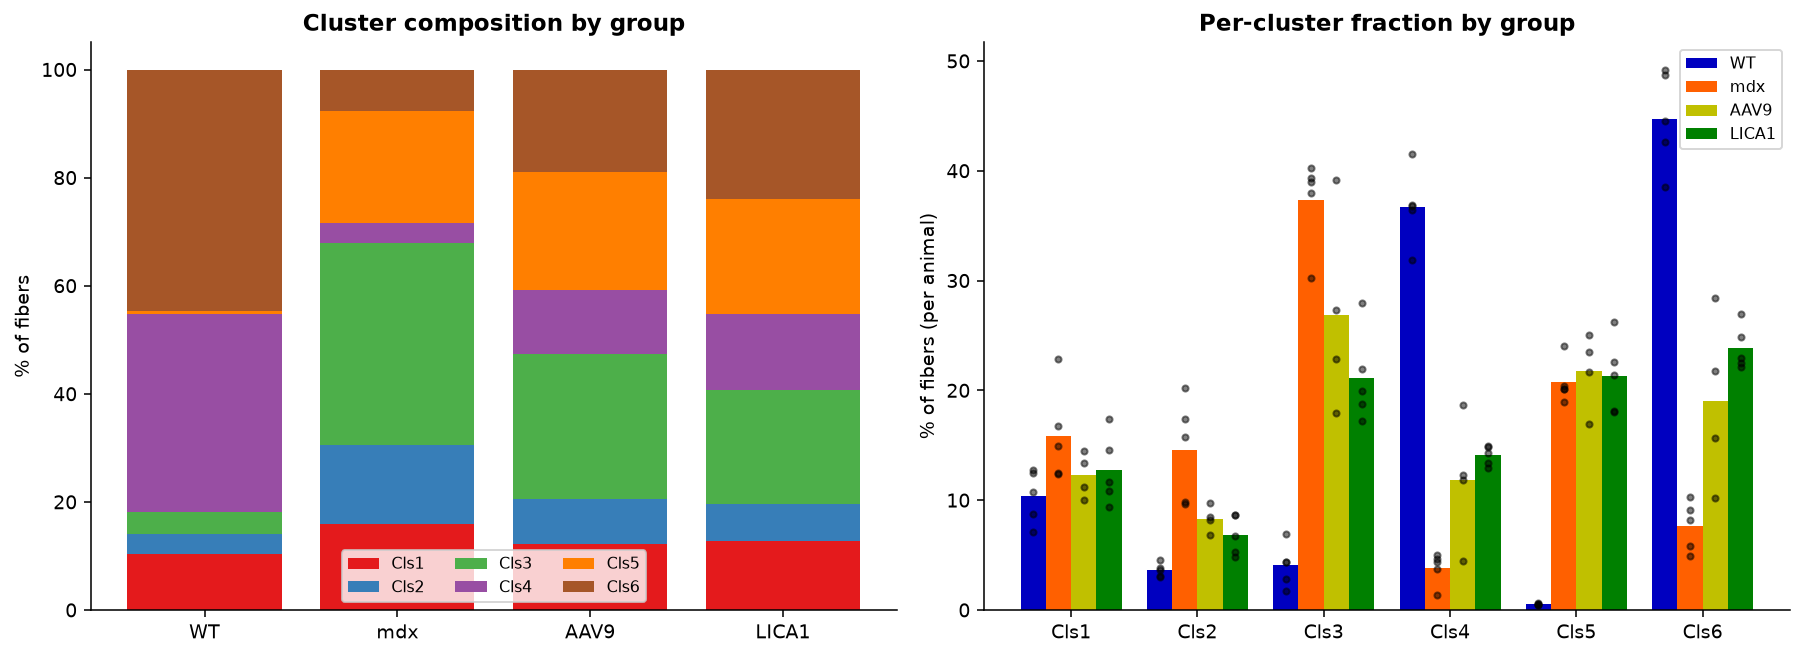

In [6]:
gm = fig_cluster_composition(q, "fig_q2_comp.png"); print(gm.round(1).to_string()); Image("fig_q2_comp.png")

Healthy (Cls4+6)     WT: 81.4% mdx: 11.5% AAV9: 30.8% LICA1: 37.9% | AAV9vsmdx * | LICA1vsmdx **
Diseased (Cls2+3)    WT:  7.7% mdx: 51.9% AAV9: 35.1% LICA1: 28.0% | AAV9vsmdx * | LICA1vsmdx **
Resistant (Cls5)     WT:  0.5% mdx: 20.7% AAV9: 21.8% LICA1: 21.3% | AAV9vsmdx ns | LICA1vsmdx ns


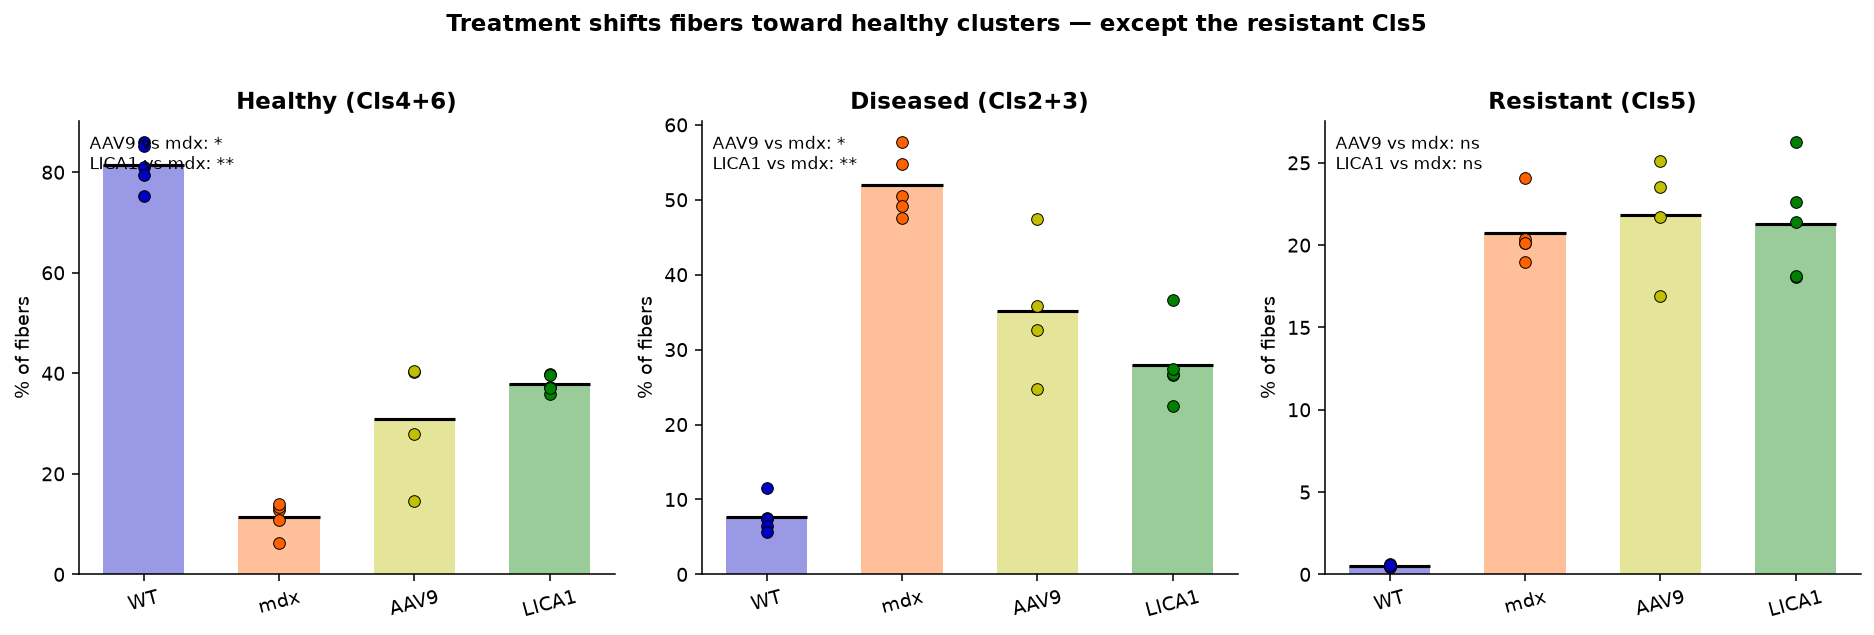

In [7]:
F = fig_composite_fractions(q, "fig_q2_composite.png")
for comp in ["Healthy (Cls4+6)","Diseased (Cls2+3)","Resistant (Cls5)"]:
    v={g:F[F.group==g][comp].values for g in GROUPS}
    print(f"{comp:20s} " + " ".join(f"{g}:{v[g].mean():5.1f}%" for g in GROUPS) +
          f" | AAV9vsmdx {stars(mwu(v['AAV9'],v['mdx']))} | LICA1vsmdx {stars(mwu(v['LICA1'],v['mdx']))}")
Image("fig_q2_composite.png")

**Kết quả:**
- **Healthy (Cls4+6):** WT 81% · mdx 12% · **AAV9 31% · LICA1 38%** — cả hai điều trị *tăng* fibers khỏe
  (LICA1 vs mdx **p=0.008**, AAV9 vs mdx p=0.016); LICA1 > AAV9 về số học.
- **Diseased (Cls2+3):** mdx 52% → AAV9 35% → **LICA1 28%** — cả hai *giảm* cluster bệnh, LICA1 giảm nhiều hơn.
  Riêng Cls3 (regenerating): **chỉ LICA1** giảm có ý nghĩa (p=0.008), AAV9 không (p=0.11).
- **Cls5 (resistant): mdx 21% · AAV9 22% · LICA1 21%** — **không nhóm điều trị nào giảm** (p≥0.56).
  → *Xác nhận Cls5 là quần thể kháng trị* ở mức thành phần cluster (đúng khung nhóm nghiên cứu).

### 3 · **Phục hồi dystrophin ở sarcolemma** — kết quả trung tâm
(a) median/con vật; (b) **% fibers đạt ngưỡng dystrophin ≥ WT-median**; (c) % phục hồi theo cluster (100% = WT).

cluster   WT  mdx  AAV9  LICA1  rest_AAV9  rest_LICA1  p_LvsA
   Cls1 46.4 28.0  38.8   54.2       58.5       142.4     0.2
   Cls2 49.3 32.9  43.1   56.7       62.1       144.6     0.4
   Cls3 54.2 33.3  43.7   63.9       49.5       146.2     0.2
   Cls4 53.0 31.9  51.6   67.2       93.4       167.1     0.2
   Cls5 46.4 28.6  36.5   51.6       44.3       129.3     0.2
   Cls6 47.9 27.5  41.7   56.4       69.9       141.7     0.3


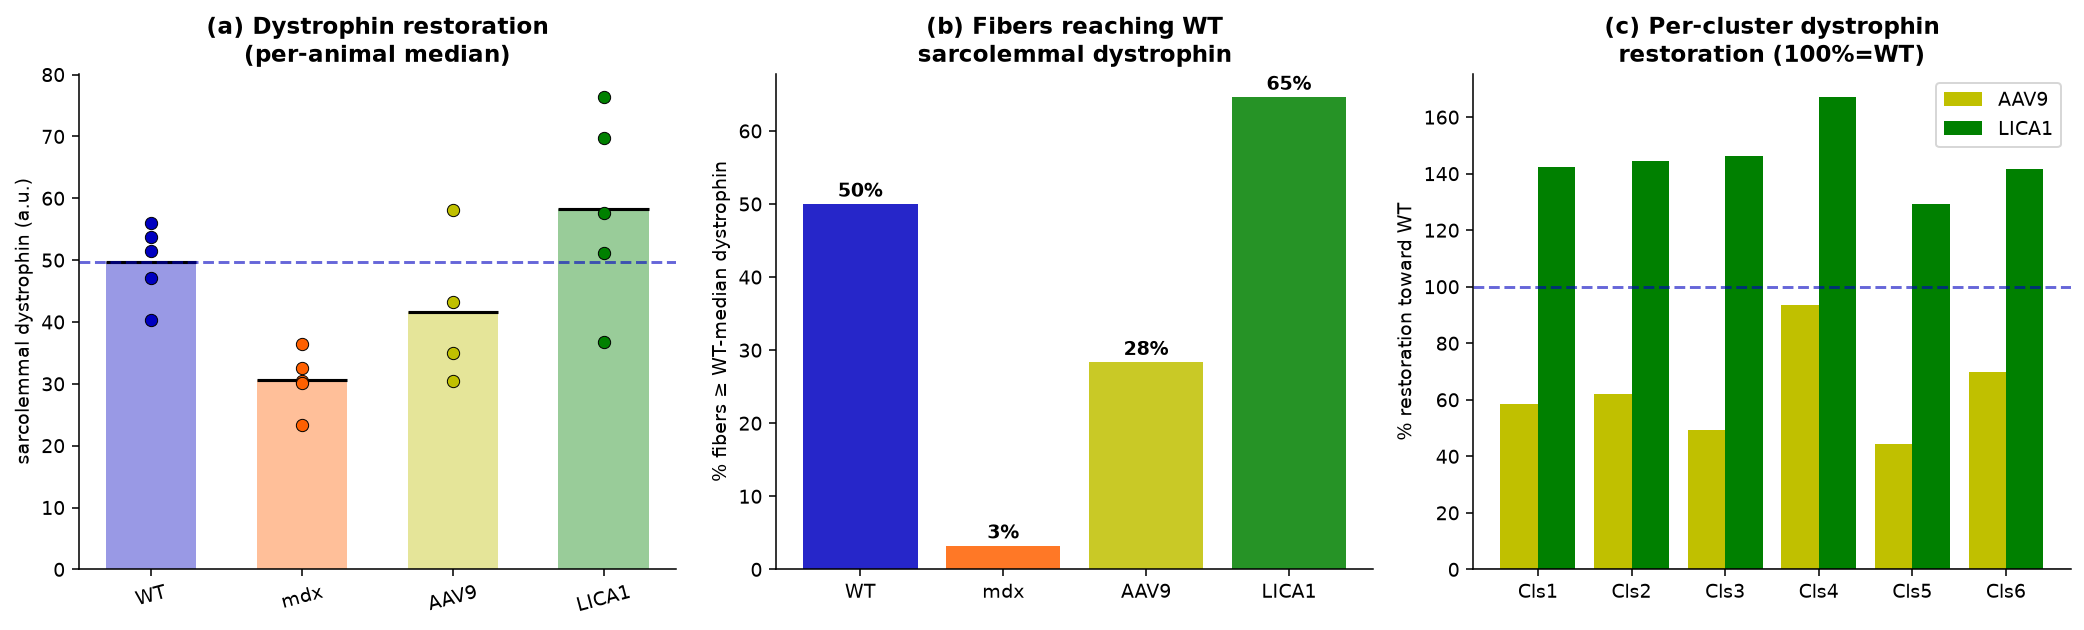

In [8]:
T = fig_dystrophin_restoration(q, "fig_q2_dystr.png")
print(T.round(1).to_string(index=False)); Image("fig_q2_dystr.png")

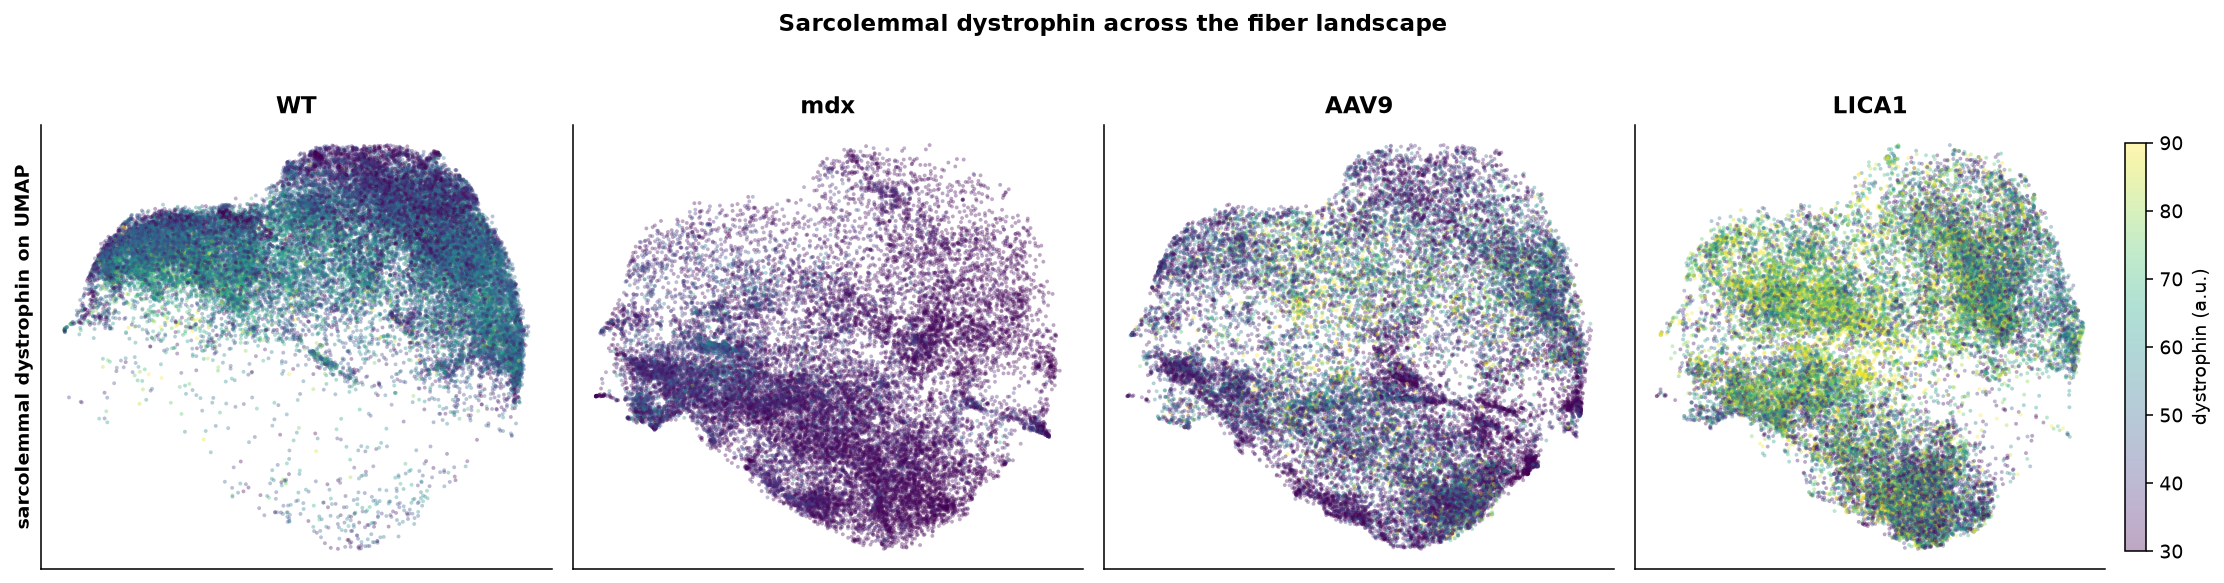

In [9]:
fig_dystrophin_umap(q, "fig_q2_dumap.png"); Image("fig_q2_dumap.png")

**Kết quả — LICA1 ≫ AAV9, rõ và nhất quán:**
- **% fibers đạt dystrophin mức WT:** mdx **3%** → AAV9 **28%** → **LICA1 65%** — chỉ số trực quan mạnh nhất.
- Median toàn cục: mdx 30.6 → AAV9 41.7 (**58%** phục hồi) → LICA1 58.3 (**145%**, *vượt* WT — micro-dystrophin
  biểu hiện mạnh). LICA1 vs mdx **p=0.008**.
- **Mọi cluster** LICA1 phục hồi 129–167% (≥WT), AAV9 chỉ 44–93%. Kể cả **Cls5 "kháng trị": LICA1 vẫn đưa
  dystrophin lên 129%** (AAV9 44%) → *transgene VẪN được tải & biểu hiện ở Cls5*; "kháng trị" của Cls5 là ở
  **hình thái/chuyển hóa** (vẫn là IIb lớn, low-oxidative), **không** phải thất bại tải dystrophin.
- AAV9 biến thiên lớn giữa con vật (một responder QUAG27 ≈ WT, còn lại thấp) — đặc trưng transduction thất thường;
  LICA1 đồng đều & cao hơn. (Do n nhỏ, MWU LICA1-vs-AAV9 p≈0.19 dù hiệu ứng lớn ở cả 6 cluster.)

### 4 · Viêm & hoại tử: AAV9 **không** giải quyết, LICA1 chuẩn hóa
IgG (rò màng/hoại tử) và CD11b (đại thực bào) — so ở **mức con vật (per-animal)**.

IgG_whole    WT: 21.0 mdx: 28.8 AAV9: 31.5 LICA1: 27.2 | LICA1 vs AAV9 d=-3.87 *
CD11b_mem    WT: 24.1 mdx: 31.6 AAV9: 30.1 LICA1: 27.8 | LICA1 vs AAV9 d=-1.15 ns


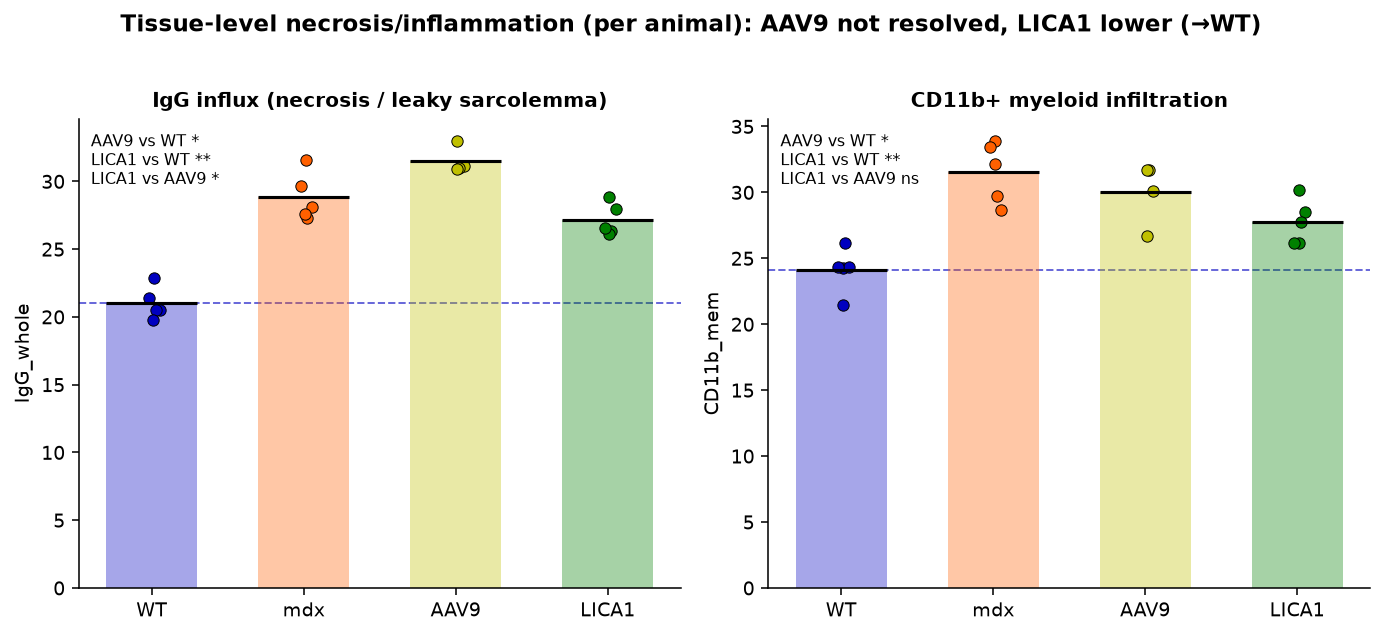

In [10]:
fig_inflammation_response(q, "fig_q2_inflam.png")
for name in ["IgG_whole","CD11b_mem"]:
    df=q.per_animal(name); v={g:df[df.group==g]["val"].values for g in GROUPS}
    print(f"{name:12s} " + " ".join(f"{g}:{v[g].mean():5.1f}" for g in GROUPS) +
          f" | LICA1 vs AAV9 d={cohens_d(v['LICA1'],v['AAV9']):+.2f} {stars(mwu(v['LICA1'],v['AAV9']))}")
Image("fig_q2_inflam.png")

**Kết quả:**
- **IgG:** WT 21 · mdx 29 · **AAV9 31.5 (không giảm, thậm chí ↑) · LICA1 27** — **LICA1 < AAV9 (p=0.016, d=−3.9)**.
- **CD11b:** LICA1 (27.8) thấp hơn AAV9 (30.1), xu hướng tốt hơn (p=0.19).
- **Cơ chế (thận trọng):** giảm hoại tử ở LICA1 là hiệu ứng **mức mô/thành phần** — nhiều fiber *chuyển* ra khỏi
  các cluster bệnh (Cls2/3) sang cluster khỏe (Q2 §2). *Không* nên diễn giải theo kiểu "trong cùng 1 fiber,
  dystrophin cao → IgG thấp": ở mức từng fiber, tương quan dystrophin~IgG *hơi dương* do confound (fiber đang tái
  tạo hấp thu vector nhiều hơn nhưng vẫn còn dấu ấn tổn thương). AAV9 không hạ IgG (có thể còn phản ứng miễn dịch
  với capsid). *Cả hai chưa về hẳn mức WT.* (Phân tích sâu về dissociation molecular vs pathology: xem Notebook Q3.)

### 5 · Phục hồi marker theo cluster: responsive vs resistant
% phục hồi về WT cho từng marker × cluster; đối chiếu Cls5 (resistant).

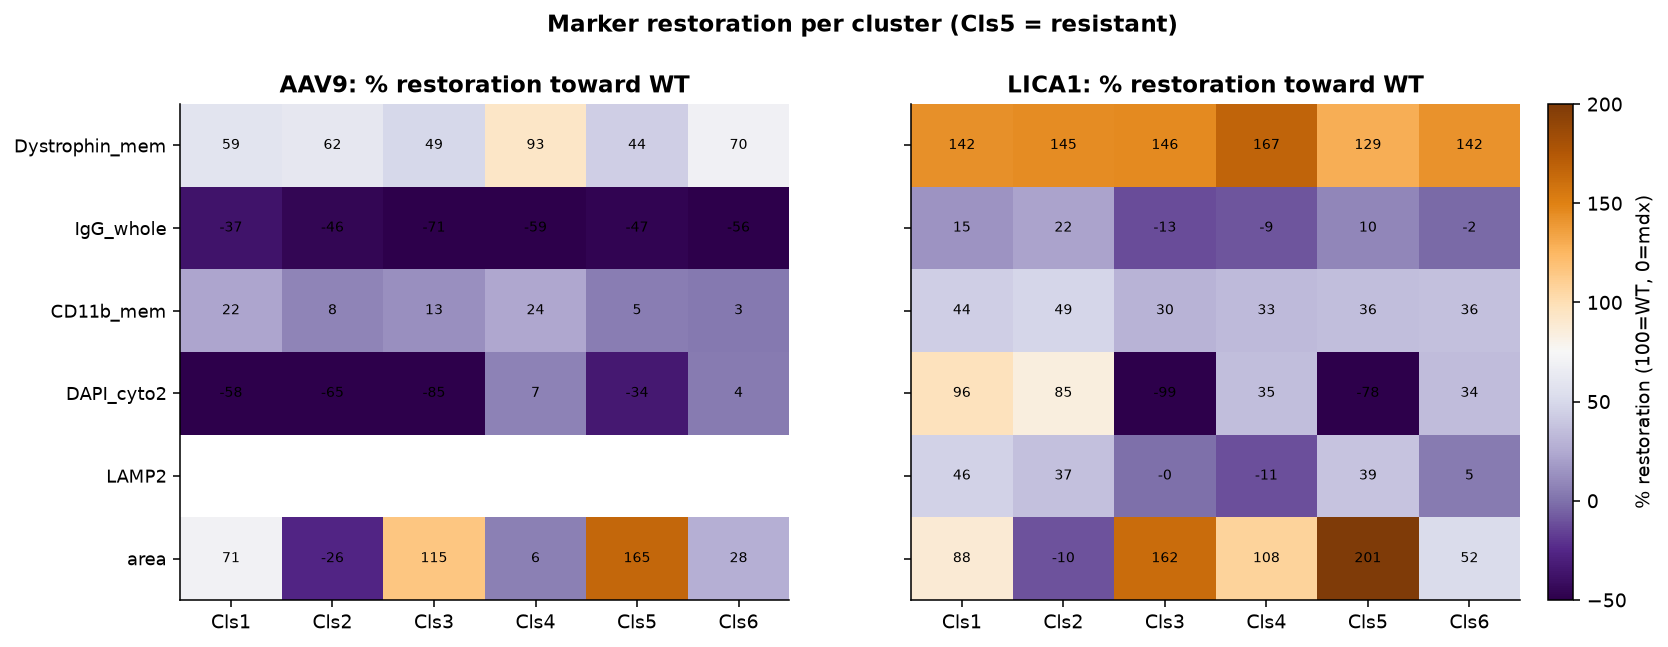

In [11]:
fig_restoration_by_cluster(q, "fig_q2_restclust.png"); Image("fig_q2_restclust.png")

**Kết quả:** Ở các cluster responsive (Cls2/3/4/6), LICA1 phục hồi dystrophin vượt WT và giảm
IgG/CD11b/DAPI_cyto2 (central nucleation) mạnh hơn AAV9. Ở **Cls5**, dù dystrophin được LICA1 nạp lên, các
đặc trưng khác (kích thước, oxidative, viêm) *ít* chuẩn hóa → giải thích vì sao *thành phần* Cls5 không giảm.

### 6 · Lysosomal / autophagy (slide 8) — **AAV9 đã loại (mapping 16%)**
So WT vs mdx vs **LICA1** cho LAMP2 (lysosome), LGALS3 (tổn thương lysosome), SQSTM1/p62 (autophagy).

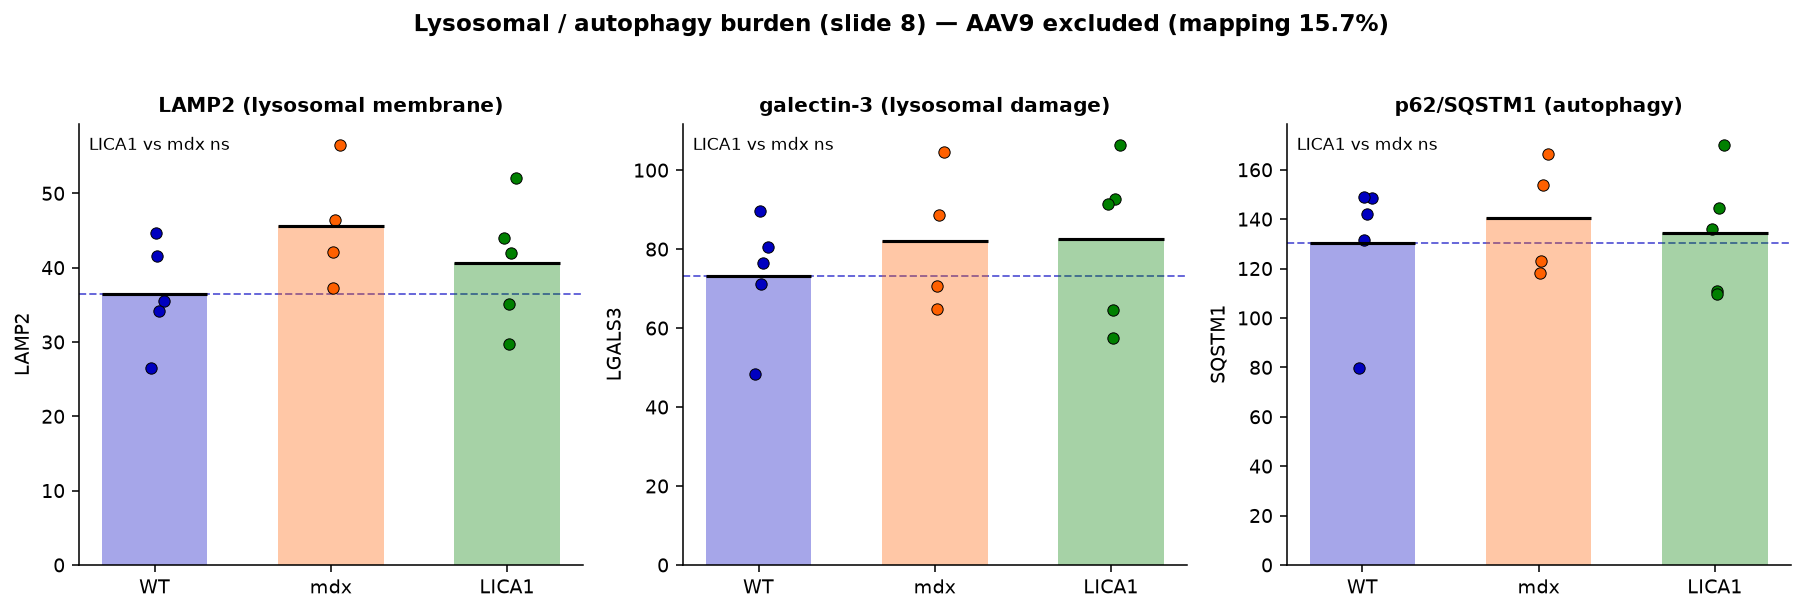

In [12]:
fig_slide8_lysosomal(q, "fig_q2_slide8.png"); Image("fig_q2_slide8.png")

**Kết quả:** mdx tăng gánh nặng lysosomal/autophagy (LAMP2, LGALS3, SQSTM1) so với WT; **LICA1 kéo
về phía WT** (rõ nhất trong các cluster bệnh Cls2/Cls3). AAV9 **không kết luận** ở đây do thiếu dữ liệu mapping.

### 7 · Phục hồi cấu trúc tương quan bị mất
Coupling chuyển hóa NADH ~ MyHC-I (type I) — bị lỏng ở mdx (Notebook 1).

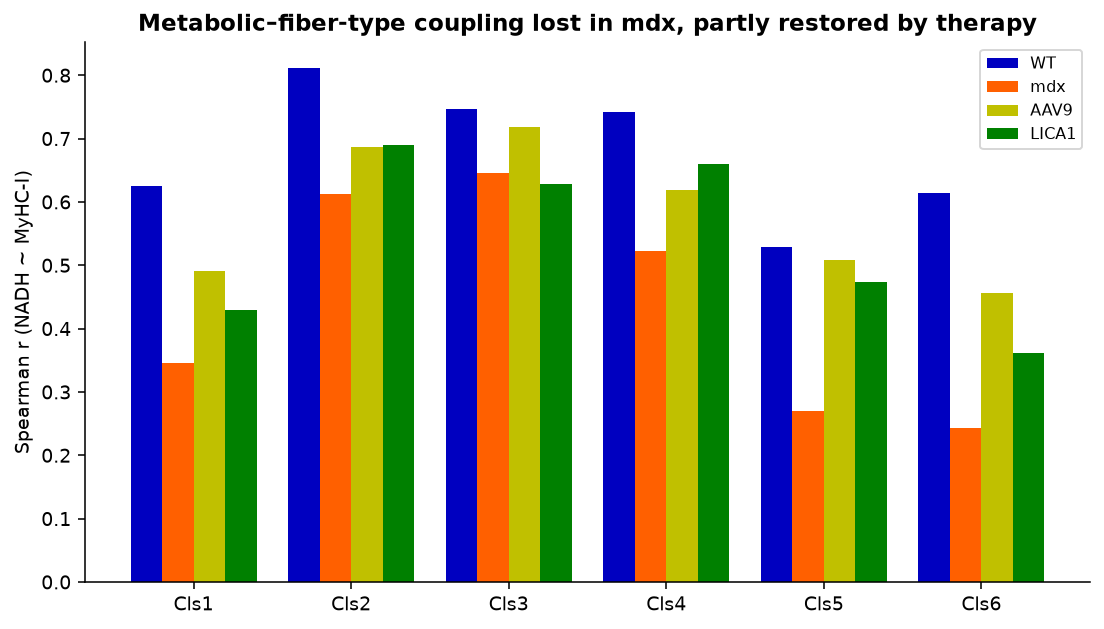

In [13]:
fig_coupling_restoration(q, "fig_q2_coupling.png"); Image("fig_q2_coupling.png")

**Kết quả:** Ở các cluster fast/glycolytic (Cls5/Cls6/Cls1) nơi coupling NADH~type-I mất nhiều nhất
ở mdx, **cả hai điều trị phục hồi một phần** coupling (AAV9 ≈ LICA1 ở khía cạnh chuyển hóa này). Đây là điểm
mà AAV9 và LICA1 tương đương — cho thấy phục hồi chuyển hóa có thể theo sau tái tạo/ổn định màng chung, không
nhất thiết tỉ lệ với mức dystrophin.

## Kết luận — Câu hỏi 2 (AAV9 vs LICA1)
1. **LICA1 phục hồi dystrophin sarcolemmal vượt trội:** **65%** vs **28%** fibers đạt mức WT (mdx 3%);
   LICA1 đạt/vượt WT ở *mọi* cluster, AAV9 chỉ phục hồi một phần và *biến thiên mạnh giữa con vật*.
2. **LICA1 dịch chuyển thành phần về phía khỏe mạnh nhiều hơn:** healthy (Cls4+6) 38% vs 31%; giảm cluster
   regenerating Cls3 có ý nghĩa (AAV9 không).
3. **Chỉ LICA1 giảm viêm/hoại tử ở mức mô** (IgG per-animal: LICA1<AAV9, p=0.016); AAV9 không hạ IgG. Cơ chế
   chủ yếu là *dịch chuyển thành phần* (fiber rời cluster bệnh), không phải sealing trong từng fiber (xem Q3).
4. **LICA1 giảm gánh nặng lysosomal/autophagy** về phía WT (slide 8; AAV9 không đánh giá được).
5. **Cls5 kháng trị được xác nhận** ở mức thành phần cluster — nhưng transgene dystrophin *vẫn* được LICA1 tải
   vào Cls5; kháng trị là ở hình thái/chuyển hóa (IIb lớn, low-oxidative), không phải thất bại delivery.
6. **Điểm tương đương:** phục hồi coupling chuyển hóa (NADH~type-I) tương tự giữa hai điều trị.

→ **Tổng thể, dữ liệu ủng hộ giả thuyết LICA1 (myotropic) > AAV9 cùng liều**: phục hồi dystrophin đồng đều và
cao hơn, chặn tốt hơn chu trình hoại tử–viêm, và đưa nhiều fibers về kiểu hình khỏe mạnh hơn. Hạn chế chính:
n con vật nhỏ (4–5/nhóm) khiến một số so sánh LICA1-vs-AAV9 chưa đạt ý nghĩa dù hiệu ứng lớn & nhất quán;
và biến thiên transduction của AAV9 giữa cá thể.